# Notebook 2 -- Crop Yield EDA by Crop, Season, State, and Agroecological Zone

**Goal:** understand the target variable before modeling.

This notebook answers:

1. Which crops dominate the NASS table by area and number of observations?
2. How different are yields across major and minor seasons?
3. How much yield variation is explained by crop identity, state, geopolitical zone, and coarse agroecological zone?
4. Which observations look unusual enough to deserve investigation?

In [1]:
# Core scientific stack
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Resolve project root whether the notebook is run from /notebooks or from the repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42


def print_section(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

# Notebook-aware figure saving -------------------------------------------------
# Every plot generated in this notebook is saved under reports/figures/.
# The counter prevents overwriting plots produced inside loops.
import re

NOTEBOOK_ID = "02_crop_yield_eda_by_zone_and_season"
_FIGURE_SAVE_COUNTER = 1


def _safe_filename(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_") or "figure"


def save_figure(fig, name: str = "figure", dpi: int = 180):
    """Save a matplotlib figure to reports/figures with a notebook-specific name."""
    global _FIGURE_SAVE_COUNTER
    filename = f"{NOTEBOOK_ID}_{_FIGURE_SAVE_COUNTER:02d}_{_safe_filename(name)}.png"
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path.relative_to(PROJECT_ROOT)}")
    _FIGURE_SAVE_COUNTER += 1
    return path


## 2.1 Loading the processed NBS table and state metadata

In [2]:
NBS_CSV = PROCESSED_DIR / "nbs_crop_yield_state_zone_2022_2023.csv"
STATE_META_CSV = PROCESSED_DIR / "state_metadata.csv"

nbs = pd.read_csv(NBS_CSV)
state_meta = pd.read_csv(STATE_META_CSV)

state_nbs = (
    nbs[~nbs["is_aggregate"].astype(bool)]
    .merge(state_meta, on="state", how="left")
    .query("yield_kg_ha.notna()")
    .copy()
)
state_nbs["log_yield_kg_ha"] = np.log1p(state_nbs["yield_kg_ha"])
state_nbs["log_planted_area_ha"] = np.log1p(state_nbs["planted_area_ha"].clip(lower=0))

print(state_nbs.shape)
display(state_nbs.head())

(490, 18)


,season,zone,state,crop,households_reporting_000,planted_area_ha,harvested_area_ha,harvested_quantity_kg,yield_kg_ha,is_aggregate,source_sheet,source_table,geopolitical_zone,agroecological_zone,latitude,longitude,log_yield_kg_ha,log_planted_area_ha
0,major,North Central,Benue,MAIZE,850.39,367795.171270,350398.700331,3.939929e+08,1124.413179,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,7.34,8.74,7.025906,12.815284
1,major,North Central,FCT,MAIZE,266.34,153246.079216,123737.798835,1.606178e+08,1298.049753,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,9.08,7.40,7.169388,11.939807
2,major,North Central,Kogi,MAIZE,640.86,327793.065371,309235.626289,4.257146e+08,1376.667527,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,7.80,6.74,7.228147,12.700141
3,major,North Central,Kwara,MAIZE,398.11,307483.872742,301489.864767,5.002011e+08,1659.097522,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,8.50,4.55,7.414632,12.636181
4,major,North Central,Nasarawa,MAIZE,520.48,416547.122485,360177.787028,4.213675e+08,1169.887511,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,8.54,8.32,7.065517,12.939757


## 2.2 Targeting variable summary

The first modeling question is whether the target is approximately symmetric or heavy-tailed. Yield datasets are often right-skewed because crops have different biological yield ranges.

,yield_kg_ha
count,490.000000
mean,2433.402346
std,2396.027869
min,194.643400
1%,294.771331
5%,571.273172
25%,1059.997266
50%,1547.714867
75%,2719.873841
95%,6813.343496


Saved figure: reports\figures\02_crop_yield_eda_by_zone_and_season_01_figure_01.png


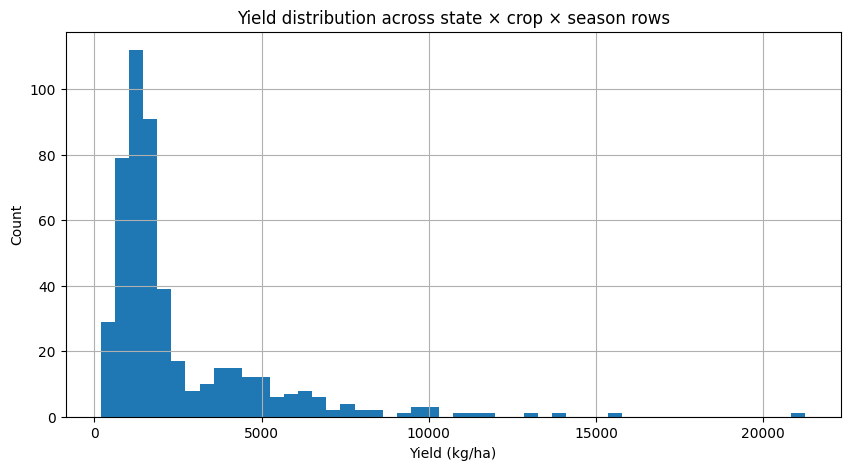

Saved figure: reports\figures\02_crop_yield_eda_by_zone_and_season_02_figure_02.png


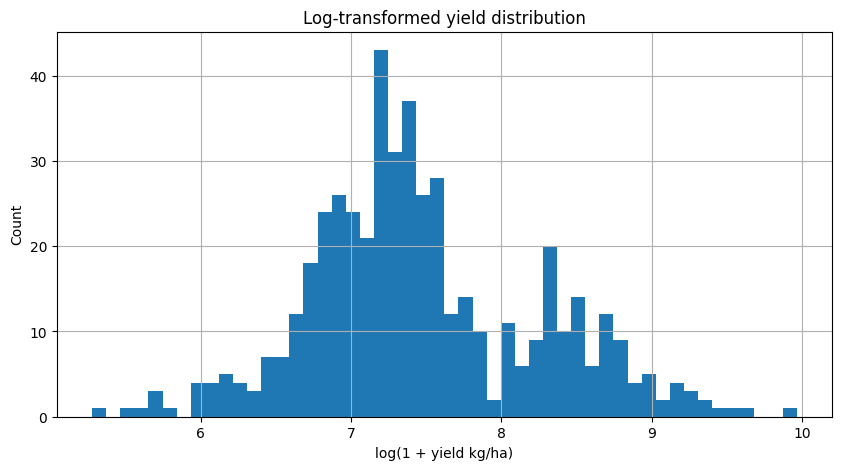

In [3]:
summary = state_nbs["yield_kg_ha"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("yield_kg_ha")
display(summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(state_nbs["yield_kg_ha"], bins=50)
ax.set_xlabel("Yield (kg/ha)")
ax.set_ylabel("Count")
ax.set_title("Yield distribution across state × crop × season rows")
save_figure(fig, "figure_01")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(state_nbs["log_yield_kg_ha"], bins=50)
ax.set_xlabel("log(1 + yield kg/ha)")
ax.set_ylabel("Count")
ax.set_title("Log-transformed yield distribution")
save_figure(fig, "figure_02")
plt.show()

## 2.3 Crop coverage and planted-area dominance

A model can be numerically accurate by doing well on dominant crops while failing on minor crops. We need to know the crop mix.

,crop,n_rows,n_states,total_planted_area_ha,median_yield_kg_ha,mean_yield_kg_ha
10,MAIZE,61,37,1.415090e+07,1363.306197,1467.816288
16,RICE,45,30,1.063089e+07,1592.923200,1673.776070
9,GUINEA CORN/SORGHUM,25,20,8.248647e+06,1055.437798,1122.953420
11,MILLET/MAIWA,24,20,6.602114e+06,958.182915,1035.750794
1,BEANS/COWPEA,26,20,5.555018e+06,934.556604,980.022075
4,CASSAVA,32,32,4.723275e+06,4734.250500,5791.175875
8,GROUNDNUT/PEANUTS,22,21,4.502839e+06,1014.572343,1045.834454
21,YAM,27,27,3.640916e+06,4994.405378,5565.289247
17,SOYA BEANS,19,19,2.470261e+06,950.705256,1015.360986
2,BEENI- SEED/SESAME,16,16,9.103115e+05,559.928988,581.576857


Saved figure: reports\figures\02_crop_yield_eda_by_zone_and_season_03_figure_03.png


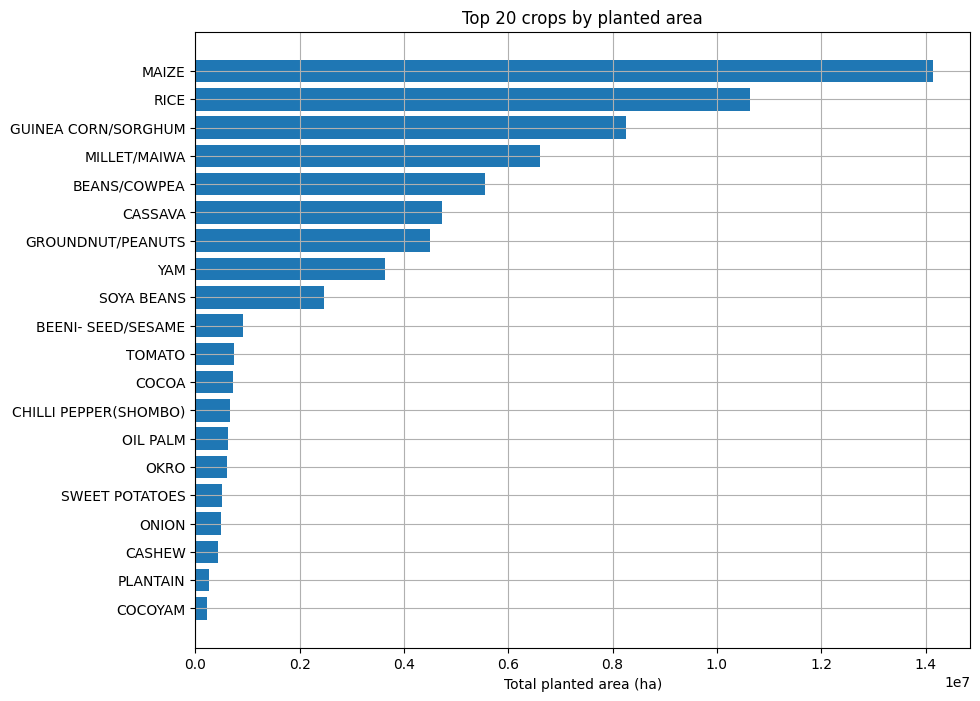

In [4]:
crop_summary = (
    state_nbs.groupby("crop", as_index=False)
    .agg(
        n_rows=("yield_kg_ha", "size"),
        n_states=("state", "nunique"),
        total_planted_area_ha=("planted_area_ha", "sum"),
        median_yield_kg_ha=("yield_kg_ha", "median"),
        mean_yield_kg_ha=("yield_kg_ha", "mean"),
    )
    .sort_values("total_planted_area_ha", ascending=False)
)

display(crop_summary.head(20))

plot_df = crop_summary.head(20).sort_values("total_planted_area_ha")
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["crop"], plot_df["total_planted_area_ha"])
ax.set_xlabel("Total planted area (ha)")
ax.set_title("Top 20 crops by planted area")
save_figure(fig, "figure_03")
plt.show()

## 2.4 Crop-specific yield distributions

The project predicts yield across multiple crops. Because different crops have different yield scales, crop identity is a critical feature and crop-wise evaluation is essential.

Saved figure: reports\figures\02_crop_yield_eda_by_zone_and_season_04_figure_04.png


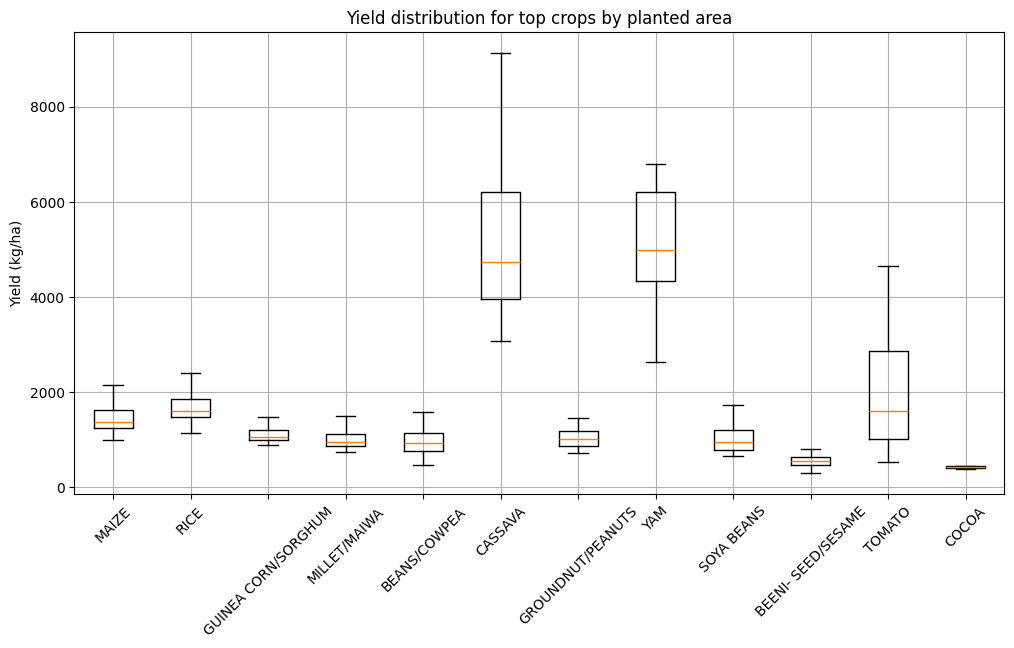

In [5]:
top_crops = crop_summary.head(12)["crop"].tolist()
plot_data = [state_nbs.loc[state_nbs["crop"].eq(c), "yield_kg_ha"].dropna().values for c in top_crops]

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(plot_data, labels=top_crops, vert=True, showfliers=False)
ax.set_ylabel("Yield (kg/ha)")
ax.set_title("Yield distribution for top crops by planted area")
ax.tick_params(axis="x", rotation=45)
save_figure(fig, "figure_04")
plt.show()

## 2.5 Season effects: major versus minor season

This tests whether the agricultural season should be treated as a separate categorical predictor.

,season,crop,n,median_yield,total_area
0,major,BANANA,6,7313.098500,3.594385e+04
1,major,BEANS/COWPEA,20,902.734133,5.451069e+06
21,minor,BEANS/COWPEA,6,1187.069050,1.039485e+05
2,major,BEENI- SEED/SESAME,16,559.928988,9.103115e+05
3,major,CASHEW,6,276.945850,4.423576e+05
4,major,CASSAVA,32,4734.250500,4.723275e+06
5,major,CHILLI PEPPER(SHOMBO),31,2040.088000,6.684461e+05
6,major,COCOA,8,419.439150,7.142631e+05
7,major,COCOYAM,16,1959.352699,2.281243e+05
8,major,GROUNDNUT/PEANUTS,20,959.262419,4.484228e+06


,major,minor,minor_minus_major,total_planted_area_ha
crop,,,,
MAIZE,1440.609876,1283.63415,-156.975726,1.415090e+07
RICE,1546.294217,1759.54270,213.248483,1.063089e+07
GUINEA CORN/SORGHUM,1057.202759,995.70910,-61.493659,8.248647e+06
MILLET/MAIWA,949.553548,1204.74485,255.191302,6.602114e+06
BEANS/COWPEA,902.734133,1187.06905,284.334917,5.555018e+06
CASSAVA,4734.250500,NaN,NaN,4.723275e+06
GROUNDNUT/PEANUTS,959.262419,1199.79010,240.527681,4.502839e+06
YAM,4994.405378,NaN,NaN,3.640916e+06
SOYA BEANS,950.705256,NaN,NaN,2.470261e+06


Saved figure: reports\figures\02_crop_yield_eda_by_zone_and_season_05_figure_05.png


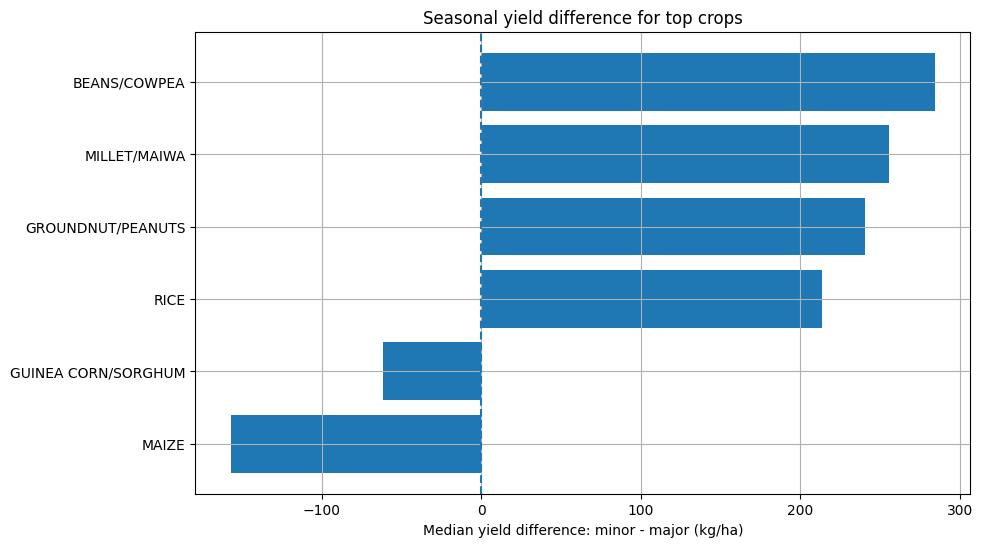

In [6]:
season_summary = (
    state_nbs.groupby(["season", "crop"], as_index=False)
    .agg(n=("yield_kg_ha", "size"), median_yield=("yield_kg_ha", "median"), total_area=("planted_area_ha", "sum"))
    .sort_values(["crop", "season"])
)
display(season_summary.head(30))

major_minor = season_summary.pivot(index="crop", columns="season", values="median_yield")
major_minor["minor_minus_major"] = major_minor.get("minor") - major_minor.get("major")
major_minor = major_minor.join(crop_summary.set_index("crop")[["total_planted_area_ha"]]).sort_values("total_planted_area_ha", ascending=False)
display(major_minor.head(20))

plot_df = major_minor.head(15).sort_values("minor_minus_major")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df.index, plot_df["minor_minus_major"])
ax.axvline(0, linestyle="--")
ax.set_xlabel("Median yield difference: minor - major (kg/ha)")
ax.set_title("Seasonal yield difference for top crops")
save_figure(fig, "figure_05")
plt.show()

## 2.6 Geopolitical and agroecological-zone comparisons

The project title uses agroecological zones. Here we make the zone effect explicit before adding satellite and climate features.


geopolitical_zone


,geopolitical_zone,n_rows,n_states,median_yield,mean_yield,total_area
3,South East,48,5,2389.841595,3197.159036,1.255852e+06
4,South South,69,6,2301.653000,3221.384023,3.634588e+06
5,South West,75,6,1985.587051,3845.081008,4.655787e+06
2,North West,108,7,1446.702735,1698.061052,2.168300e+07
0,North Central,110,7,1295.516636,2094.977971,1.745965e+07
1,North East,80,6,1152.458115,1430.109654,1.824137e+07



agroecological_zone


,agroecological_zone,n_rows,n_states,median_yield,mean_yield,total_area
3,Mangrove / Coastal Rainforest,28,3,3084.351629,3608.340877,6.472048e+05
2,Humid Forest / Mangrove,24,2,2667.492860,3074.585605,1.443840e+06
1,Humid Forest,30,3,2196.365111,3868.938473,1.760398e+06
0,Derived Savannah / Humid Forest Transition,110,9,1981.079788,3392.985942,5.694784e+06
7,Sahel Savannah,18,1,1600.901607,1982.765413,1.399695e+06
9,Sudan Savannah,88,6,1344.298419,1495.089204,2.096339e+07
8,Southern Guinea Savannah,96,6,1295.516636,2121.831424,1.495777e+07
5,Northern Guinea Savannah,48,3,1291.720506,1809.745521,1.164965e+07
4,Montane / Northern Guinea Savannah,14,1,1266.426825,1910.840008,2.501883e+06
6,Sahel / Sudan Savannah,34,3,1145.781816,1284.528044,5.911643e+06


Saved figure: reports\figures\02_crop_yield_eda_by_zone_and_season_06_figure_06.png


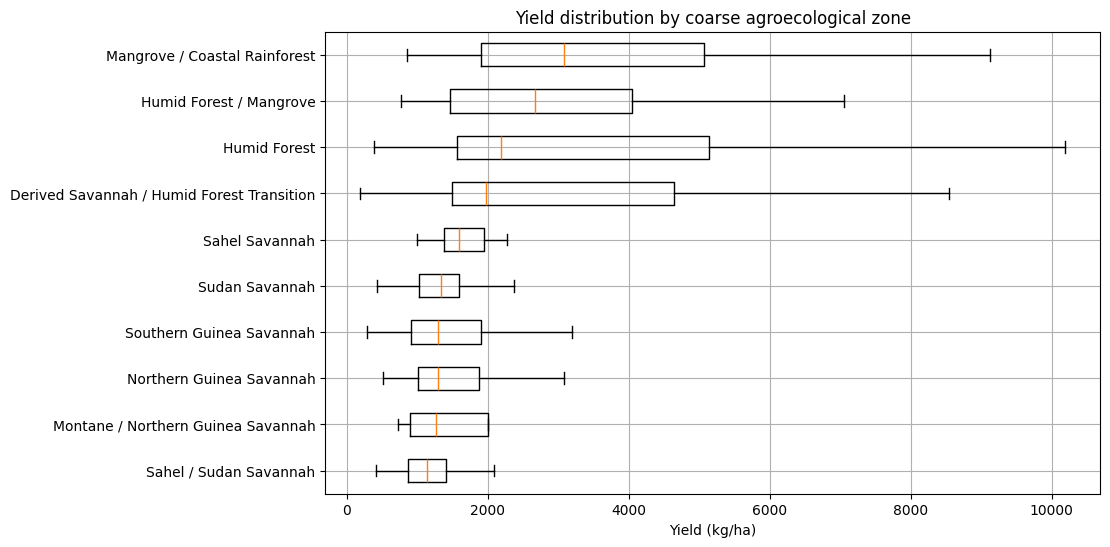

In [7]:
for zone_col in ["geopolitical_zone", "agroecological_zone"]:
    zone_summary = (
        state_nbs.groupby(zone_col, as_index=False)
        .agg(
            n_rows=("yield_kg_ha", "size"),
            n_states=("state", "nunique"),
            median_yield=("yield_kg_ha", "median"),
            mean_yield=("yield_kg_ha", "mean"),
            total_area=("planted_area_ha", "sum"),
        )
        .sort_values("median_yield", ascending=False)
    )
    print_section(zone_col)
    display(zone_summary)

fig, ax = plt.subplots(figsize=(10, 6))
zone_order = state_nbs.groupby("agroecological_zone")["yield_kg_ha"].median().sort_values().index.tolist()
plot_data = [state_nbs.loc[state_nbs["agroecological_zone"].eq(z), "yield_kg_ha"].dropna().values for z in zone_order]
ax.boxplot(plot_data, labels=zone_order, vert=False, showfliers=False)
ax.set_xlabel("Yield (kg/ha)")
ax.set_title("Yield distribution by coarse agroecological zone")
save_figure(fig, "figure_06")
plt.show()

## 2.7 State-level crop maps using centroid scatter plots

This is a lightweight spatial diagnostic, but it helps identify spatial gradients without requiring a shapefile.

Saved figure: reports\figures\02_crop_yield_eda_by_zone_and_season_07_figure_07.png


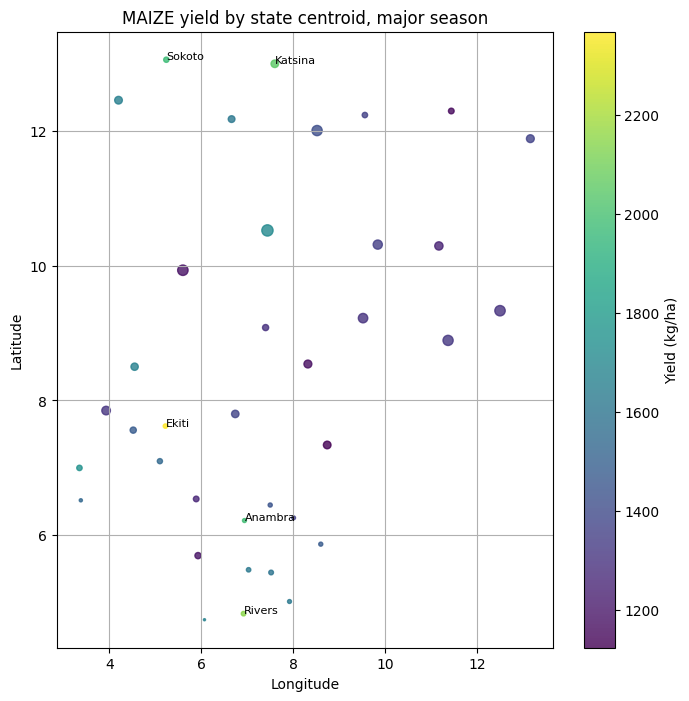

In [8]:
selected_crop = "MAIZE" if "MAIZE" in state_nbs["crop"].unique() else state_nbs["crop"].mode().iloc[0]
map_df = state_nbs.query("crop == @selected_crop and season == 'major'").copy()

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(
    map_df["longitude"],
    map_df["latitude"],
    c=map_df["yield_kg_ha"],
    s=np.sqrt(map_df["planted_area_ha"].clip(lower=1)) / 20,
    alpha=0.8,
)
for _, row in map_df.nlargest(5, "yield_kg_ha").iterrows():
    ax.annotate(row["state"], (row["longitude"], row["latitude"]), fontsize=8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"{selected_crop} yield by state centroid, major season")
plt.colorbar(sc, ax=ax, label="Yield (kg/ha)")
save_figure(fig, "figure_07")
plt.show()

## 2.8 Relationship between planted area and yield

A large planted area does not automatically imply high yield. This plot also highlights why scale transformations are useful.

Saved figure: reports\figures\02_crop_yield_eda_by_zone_and_season_08_figure_08.png


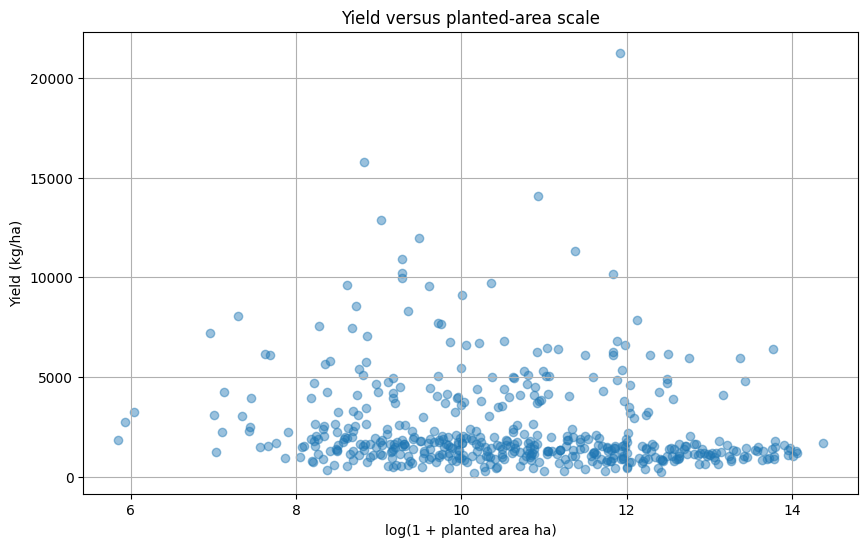

,yield_kg_ha,log_yield_kg_ha,planted_area_ha,log_planted_area_ha,latitude,longitude
yield_kg_ha,1.000000,0.882096,-0.138405,-0.158317,-0.295239,-0.230107
log_yield_kg_ha,0.882096,1.000000,-0.151112,-0.210549,-0.313482,-0.252326
planted_area_ha,-0.138405,-0.151112,1.000000,0.744664,0.256913,0.197375
log_planted_area_ha,-0.158317,-0.210549,0.744664,1.000000,0.346053,0.219429
latitude,-0.295239,-0.313482,0.256913,0.346053,1.000000,0.244644
longitude,-0.230107,-0.252326,0.197375,0.219429,0.244644,1.000000


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(state_nbs["log_planted_area_ha"], state_nbs["yield_kg_ha"], alpha=0.45)
ax.set_xlabel("log(1 + planted area ha)")
ax.set_ylabel("Yield (kg/ha)")
ax.set_title("Yield versus planted-area scale")
save_figure(fig, "figure_08")
plt.show()

corr = state_nbs[["yield_kg_ha", "log_yield_kg_ha", "planted_area_ha", "log_planted_area_ha", "latitude", "longitude"]].corr()
display(corr)

## 2.9 Outlier table for manual review

Outliers are not deleted automatically. Instead, we produce a transparent table so you can decide whether they are valid crop/state realities or parsing/data-quality issues.

In [10]:
q_low, q_high = state_nbs["yield_kg_ha"].quantile([0.01, 0.99])
outliers = state_nbs[(state_nbs["yield_kg_ha"] <= q_low) | (state_nbs["yield_kg_ha"] >= q_high)].copy()
outliers = outliers.sort_values("yield_kg_ha", ascending=False)

display(outliers[["season", "state", "crop", "zone", "agroecological_zone", "planted_area_ha", "harvested_area_ha", "yield_kg_ha"]].head(30))

outlier_path = TABLES_DIR / "eda_yield_outliers_for_review.csv"
outliers.to_csv(outlier_path, index=False)
print("Saved:", outlier_path)

,season,state,crop,zone,agroecological_zone,planted_area_ha,harvested_area_ha,yield_kg_ha
101,major,Cross River,CASSAVA,South South,Humid Forest,151007.447100,151007.44710,21265.399000
262,major,Kwara,TOMATO,North Central,Southern Guinea Savannah,6784.487270,6509.72186,15759.468700
142,major,Ekiti,YAM,South West,Derived Savannah / Humid Forest Transition,55392.861008,25224.93402,14092.866677
851,minor,Ekiti,WHITEYAM,South West,Derived Savannah / Humid Forest Transition,8288.124000,1744.41800,12875.969000
290,major,Ekiti,TOMATO,South West,Derived Savannah / Humid Forest Transition,13185.208420,11147.59471,11971.603100
298,major,Kogi,CASHEW,North Central,Southern Guinea Savannah,124870.800000,124870.80000,292.858900
362,major,Edo,COCOA,South South,Derived Savannah / Humid Forest Transition,60116.839350,60116.83935,285.808700
331,major,Osun,CASHEW,South West,Derived Savannah / Humid Forest Transition,29417.600000,29417.60000,261.032800
332,major,Oyo,CASHEW,South West,Derived Savannah / Humid Forest Transition,248368.800000,248368.80000,240.298300
325,major,Edo,CASHEW,South South,Derived Savannah / Humid Forest Transition,25763.760000,25763.76000,194.643400


Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai-v2\reports\tables\eda_yield_outliers_for_review.csv
